# Análisis Exploratorio de Datos (EDA): Mercado Inmobiliario de California
## 1. Contexto y Objetivo
Este análisis audita un conjunto de datos del mercado inmobiliario de California con el objetivo de aislar y cuantificar las variables fundamentales que dictan el precio de las viviendas. Se busca ir más allá de los datos crudos, detectando anomalías estructurales e inyectando nuevas variables para descubrir patrones subyacentes.

## 2. Resumen Ejecutivo
* **El Dominio del Ingreso:** La capacidad económica (`median_income`) es el vector gravitacional más fuerte que impulsa los precios al alza.
* **Anomalías Detectadas:** Se identificaron y documentaron techos artificiales rígidos en las variables de precio máximo ($500,001) y edad de la vivienda (52 años) que distorsionan el mercado.
* **El Impacto del Diseño Estructural:** La variable sintética `bedrooms_per_room` demostró que los inmuebles de mayor valor destinan una proporción significativamente menor de su espacio a dormitorios.

In [1]:
#importaciones
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)


#carga del dataset con ruta relativa y compatible con Kaggle
if os.path.exists('/kaggle/input'):
    #ruta dinamica en los servidores de Kaggle
    data_path = '/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv'
else:
    #ruta de desarrollo local
    data_path = '../data/raw/housing.csv'

#cargar el dataset desde la ruta detectada
df = pd.read_csv(data_path)

#vista previa de datos
print('Vista previa de datos:')
display(df.head(10))

#estructura y tipo de datos
print('Estructura y tipo de datos:')
df.info()

#dimensiones del dataset
print("Dimensiones del dataset:")
df.shape



Vista previa de datos:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


Estructura y tipo de datos:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
Dimensiones del dataset:


(20640, 10)

## Análisis Univariado: La Variable Objetivo (Precios)
Exploración de la distribución de `median_house_value` para detectar anomalías, sesgos y la morfología general del mercado inmobiliario.

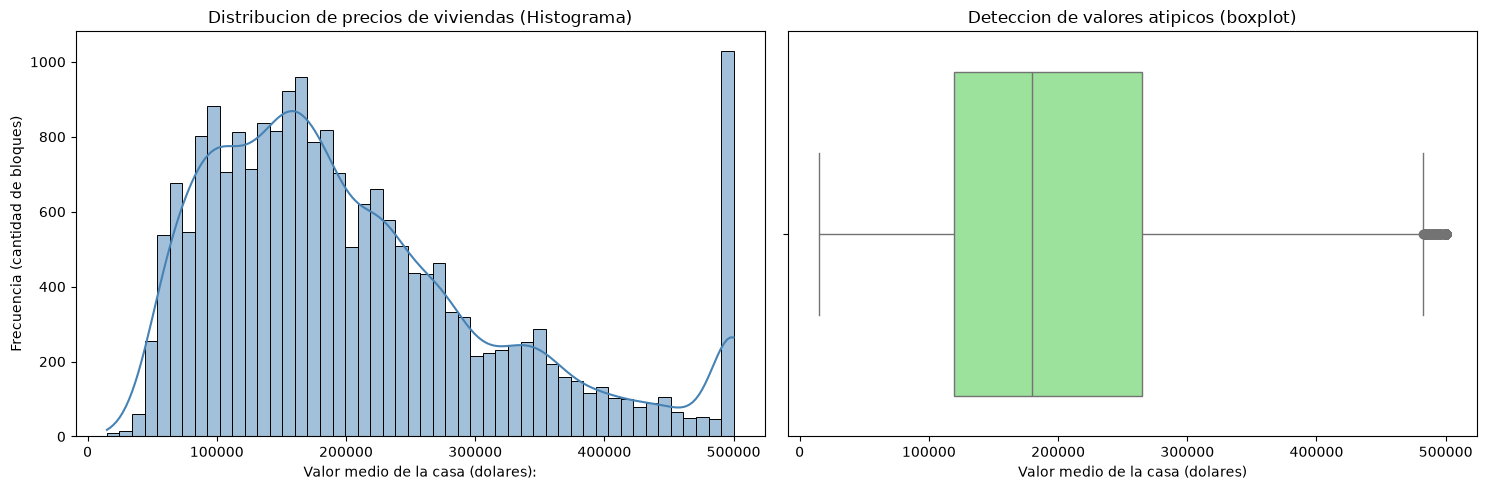

In [2]:
#Análisis univariado

#preparacion de matplotlib
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

#pintar el histograma en el espacio izquierdo
sns.histplot(data=df, x='median_house_value', bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribucion de precios de viviendas (Histograma)')
axes[0].set_xlabel('Valor medio de la casa (dolares):')
axes[0].set_ylabel('Frecuencia (cantidad de bloques)')

#pintar el boxplot en el espacio derecho
sns.boxplot(data=df, x='median_house_value', ax=axes[1], color='lightgreen')
axes[1].set_title('Deteccion de valores atipicos (boxplot)')
axes[1].set_xlabel('Valor medio de la casa (dolares)')

#ajustar y mostrar
plt.tight_layout()
plt.show()

## Análisis Univariado: El Poder Adquisitivo (Ingresos)
Análisis visual de la columna `median_income` para determinar la distribución de la riqueza en los bloques censales.

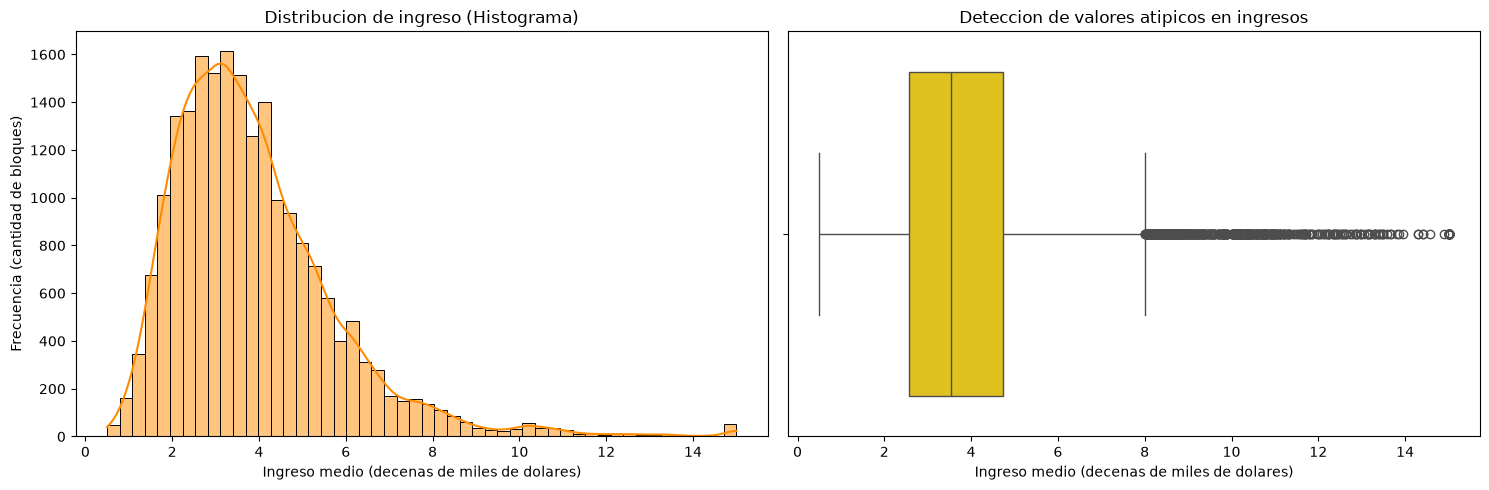

In [3]:
#figura con dos subplots en paralelo: histograma y boxplot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

#histograma de ingresos
sns.histplot(data=df, x='median_income', bins=50, kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Distribucion de ingreso (Histograma)')
axes[0].set_xlabel('Ingreso medio (decenas de miles de dolares)')
axes[0].set_ylabel('Frecuencia (cantidad de bloques)')

#boxplot de ingresos (deteccion matematica de anomalias)
sns.boxplot(data=df, x='median_income', ax=axes[1], color='gold')
axes[1].set_title('Deteccion de valores atipicos en ingresos')
axes[1].set_xlabel('Ingreso medio (decenas de miles de dolares)')

plt.tight_layout()
plt.show()

## Análisis Bivariado: Ingresos vs Precios
Evaluación de la correlación lineal entre el poder adquisitivo del bloque censal y el valor de las propiedades.

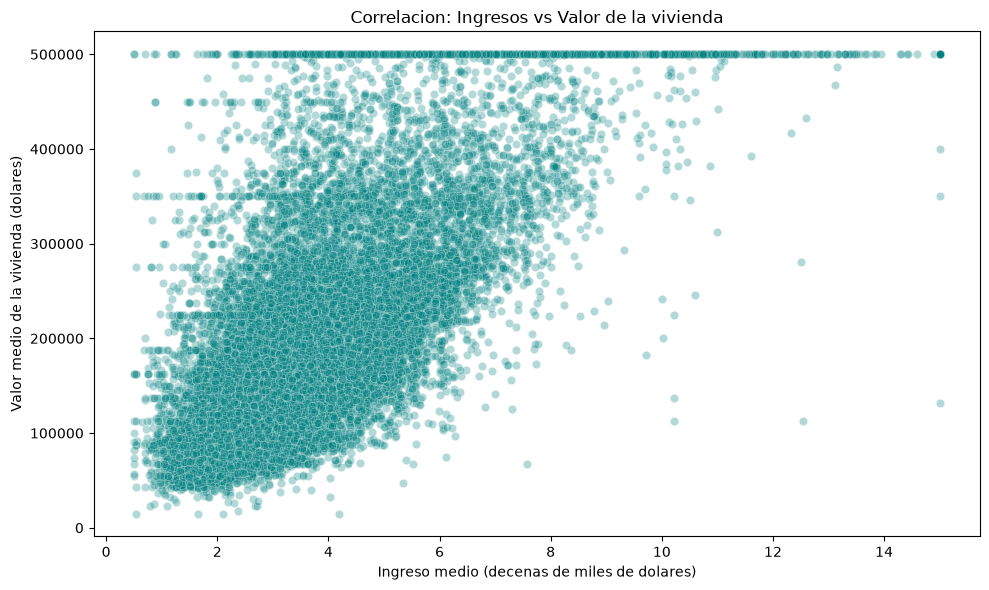

In [4]:
#Análisis bivariado
plt.figure(figsize=(10, 6))

#dibujar la dispersion de puntos con transparencia (alpha) para ver la densidad
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.3, color='teal')

plt.title('Correlacion: Ingresos vs Valor de la vivienda')
plt.xlabel('Ingreso medio (decenas de miles de dolares)')
plt.ylabel('Valor medio de la vivienda (dolares)')

plt.tight_layout()
plt.show()

## Verificación de Techos Artificiales
Uso del filtrado de pandas para cuantificar la densidad de registros en el limite superior de `median_income`, `median_house_value` y `housing_median_age`

In [5]:
#MEDIAN_INCOME

#encontrar el valor matematico mas alto de la columna median_income
ingreso_max = df['median_income'].max()

#aislar/filtrar filas que tengan exactamente ese valor
bloques_tope_ingresos = df[df['median_income'] == ingreso_max]

#contar cuantos son
cantidad_bloques_ingreso = len(bloques_tope_ingresos)

#calcular que porcentaje del total representa
porcentaje_ingreso_tope = (cantidad_bloques_ingreso/len(df)) * 100

print('Reporte de posible anomalia (median_income)')
print(f'Valor maximo registrado: {ingreso_max}')
print(f'Cantidad de bloques con ese valor: {cantidad_bloques_ingreso}')
print(f'Porcentaje del dataset: {porcentaje_ingreso_tope:.2f}%')


Reporte de posible anomalia (median_income)
Valor maximo registrado: 15.0001
Cantidad de bloques con ese valor: 49
Porcentaje del dataset: 0.24%


In [6]:
#MEDIAN_HOUSE_VALUE
precio_max = df['median_house_value'].max()
bloques_tope_precio = df[df['median_house_value'] == precio_max]
porcentaje_precio_tope = (len(bloques_tope_precio) / len(df)) * 100

print('Reporte de posible anomalia (median_house_value)')
print(f'Valor maximo registrado: {precio_max}')
print(f'Cantidad de bloques con ese valor: {len(bloques_tope_precio)}')
print(f'Porcentaje del dataset: {porcentaje_precio_tope:.2f}%')

Reporte de posible anomalia (median_house_value)
Valor maximo registrado: 500001.0
Cantidad de bloques con ese valor: 965
Porcentaje del dataset: 4.68%


In [7]:
#HOUSING_MEDIAN_AGE
edad_max = df['housing_median_age'].max()
bloques_tope_edad = df[df['housing_median_age'] == edad_max]
porcentaje_edad_tope = (len(bloques_tope_edad) / len(df)) * 100

print('Reporte de posible anomalia (housing_median_age)')
print(f'Valor maximo registrado: {edad_max}')
print(f'Cantidad de bloques con ese valor: {len(bloques_tope_edad)}')
print(f'Porcentaje del dataset: {porcentaje_edad_tope:.2f}%')

Reporte de posible anomalia (housing_median_age)
Valor maximo registrado: 52.0
Cantidad de bloques con ese valor: 1273
Porcentaje del dataset: 6.17%


## Análisis de Datos Faltantes
Aislamiento y Análisis de los registros con valores nulos en la columna `total_bedrooms`.

In [8]:
#crear dataframe con los valores nulos
filas_rotas = df[df['total_bedrooms'].isnull()]
porcentaje_nulos = (len(filas_rotas)/len(df)) * 100
print(f"Total de filas con nulos aisladas: {len(filas_rotas)}")
print(f"Porcentaje de filas con nulos: {porcentaje_nulos:.2f}%")
print("\nVista previa de las primeras 10 filas con valor nulo")
display(filas_rotas.head(10))



Total de filas con nulos aisladas: 207
Porcentaje de filas con nulos: 1.00%

Vista previa de las primeras 10 filas con valor nulo


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
738,-122.14,37.67,37.0,3342.0,NaN,1635.0,557.0,4.7933,186900.0,NEAR BAY
1097,-121.77,39.66,20.0,3759.0,NaN,1705.0,600.0,4.7120,158600.0,INLAND
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,143100.0,INLAND
1456,-121.98,37.96,22.0,2987.0,NaN,1420.0,540.0,3.6500,204100.0,INLAND
1493,-122.01,37.94,23.0,3741.0,NaN,1339.0,499.0,6.7061,322300.0,NEAR BAY


## Construccion de Dataset Curado de valores nulos
Curación de la columna `total_bedrooms` mediante la imputación de la mediana espacial para preservar la varianza del dataset sin eliminar registros.

In [9]:
#curacion de datos
nota = '''
Si bien rellenar con la mediana sigue siendo un sesgo matematico minusculo, cuando representa menos del 3% o el 5%
es casi insignificante, en este caso el porcentaje de valores nulos representa el 1%
'''
#calcular la mediana exacta de los dormitorios
mediana_dormitorios = df['total_bedrooms'].median()
print(f"Mediana calculada para curacion: {mediana_dormitorios}")

#inyectar este valor unicamente en los huecos nulos NaN
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_dormitorios) #con esto se rellena los valore NaN

#confirmacion
nulos_restantes = df['total_bedrooms'].isnull().sum()
assert nulos_restantes == 0
print(f"Columna limpiada. Nulos restantes en la columna: {nulos_restantes}")
print(nota)


Mediana calculada para curacion: 435.0
Columna limpiada. Nulos restantes en la columna: 0

Si bien rellenar con la mediana sigue siendo un sesgo matematico minusculo, cuando representa menos del 3% o el 5%
es casi insignificante, en este caso el porcentaje de valores nulos representa el 1%



## Sintesis de Variables Estructurales (Ratios)
Creación de proporciones espaciales y demográficas para dotar al algoritmo de contexto sobre el nivel de hacinamiento y calidad arquitectónica.

In [10]:
#habitaciones por hogar, metrica lujo/amplitud
df['rooms_per_household'] = df['total_rooms'] / df['households']

#dormitorios por habitacion, metrica de utilidad arquitectonica
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

#personas por hogar, metrica de densidad
df['population_per_household'] = df['population'] / df['households']

#visualizacion de nuevos datos
print('Vista previa de nuevos datos')
display(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

Vista previa de nuevos datos


,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


## Exploración Visual de Relaciones (Pairplot)
Inspección simultánea de las relaciones entre variables clave y la variable objetivo.
Cada celda muestra la dispersión entre dos variables, la diagonal muestra la densidad
individual de cada una. Complementa el heatmap de Pearson con la forma visual de cada relación.

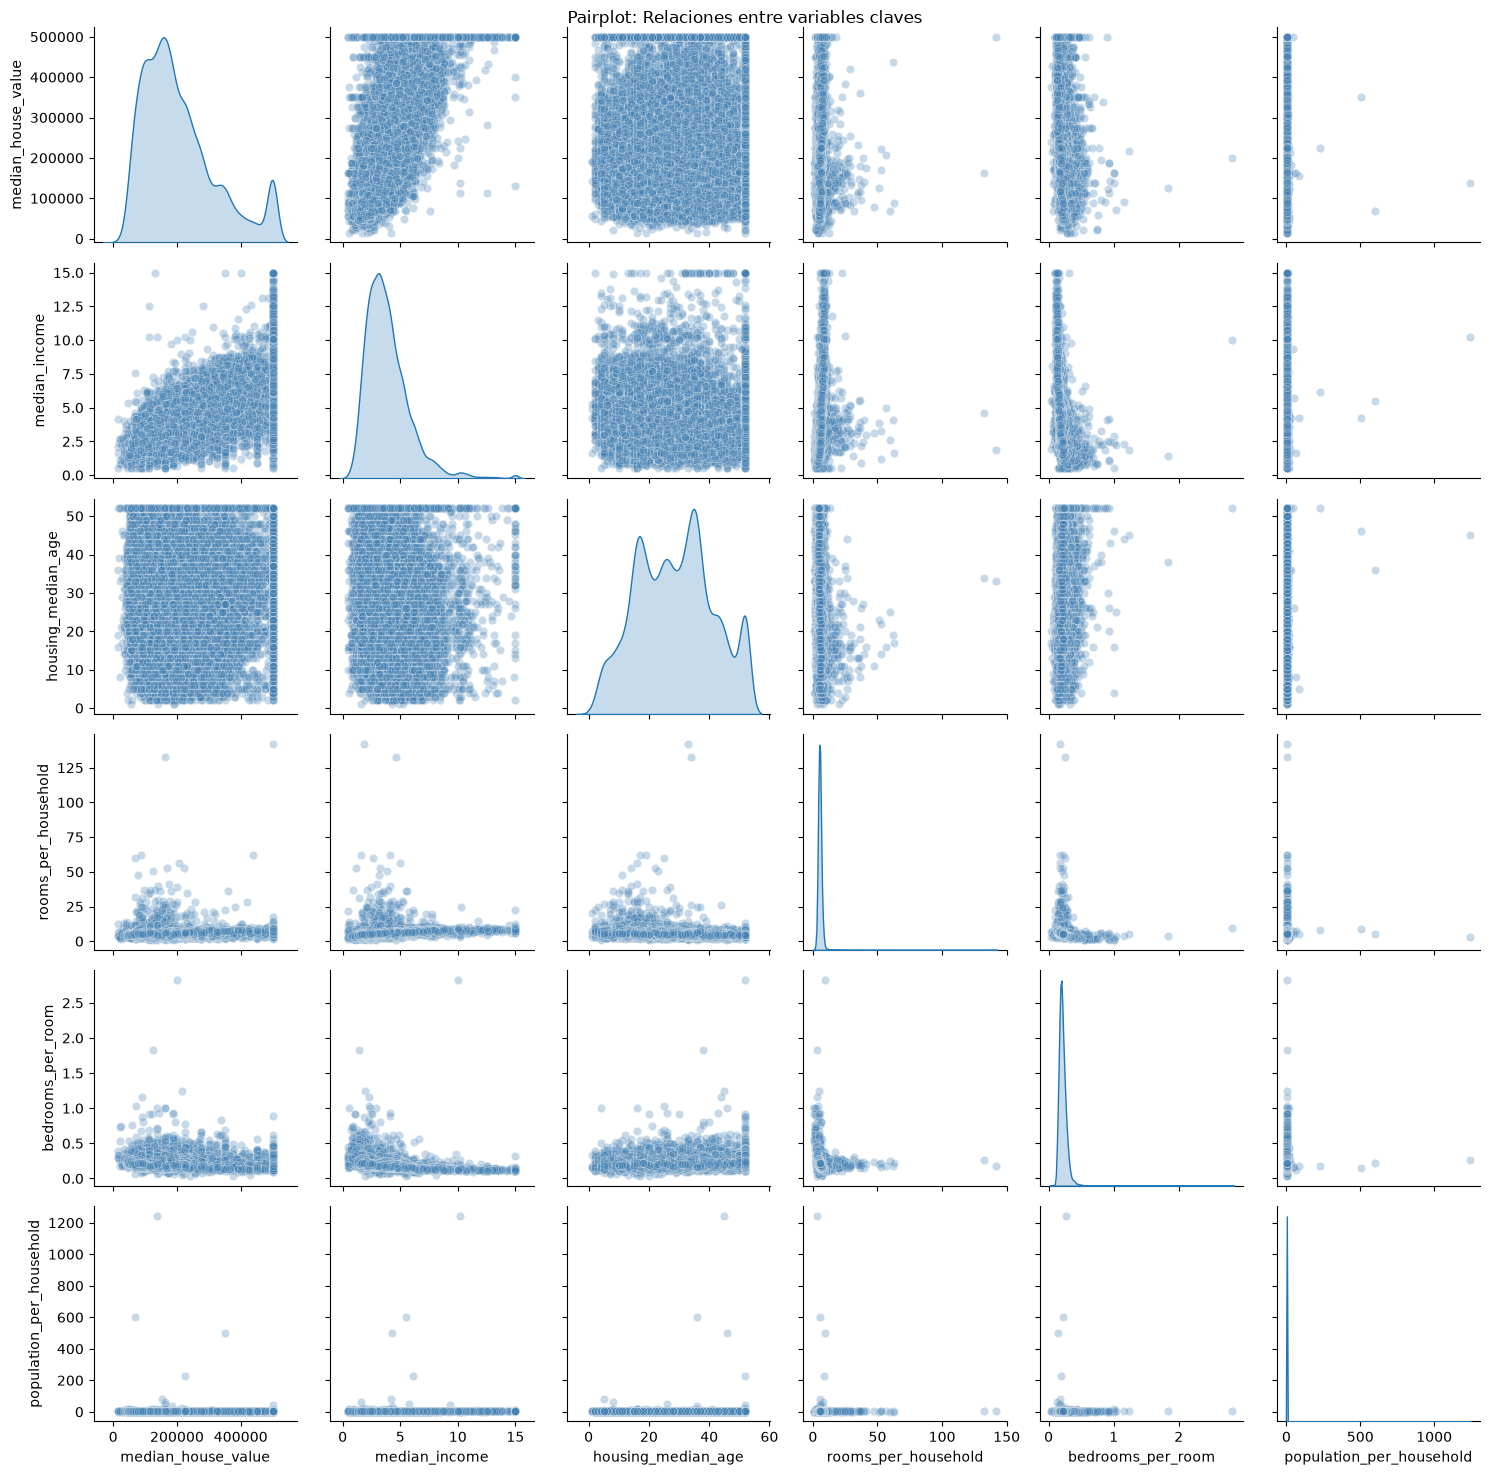

In [11]:
#Pairplot, relaciones entre variables
columnas_pairplot = [
    'median_house_value',
    'median_income',
    'housing_median_age',
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household'
]

#df original (sin limpiar): el objetivo es detectar outliers y techos antes de curar
sns.pairplot(
    df[columnas_pairplot],
    diag_kind='kde', #distrubucion de la diagonal
    plot_kws={'alpha': 0.3, 'color': 'steelblue'}, #transparencia para ver la densidad
)

plt.suptitle('Pairplot: Relaciones entre variables claves')
plt.tight_layout()
plt.show()

## Filtrado por percentil 99 en ratios
Los ratios tienen outliers extremos (edificios institucionales, errores de carga) que distorsionan la escala de los graficos

In [12]:
#el percentil 99 es el corte matematico estandar, elimina el 1% mas extremo
p99_rooms      = df['rooms_per_household'].quantile(0.99)
p99_bedrooms   = df['bedrooms_per_room'].quantile(0.99)
p99_population = df['population_per_household'].quantile(0.99)

print(f'Corte p99 rooms_per_household:      {p99_rooms:.2f}')
print(f'Corte p99 bedrooms_per_room:        {p99_bedrooms:.2f}')
print(f'Corte p99 population_per_household: {p99_population:.2f}')

Corte p99 rooms_per_household:      10.36
Corte p99 bedrooms_per_room:        0.42
Corte p99 population_per_household: 5.39


## Construcción del Dataset Curado (df_clean)
Aplicación de los filtros identificados: remoción del techo artificial de
`median_house_value` y exclusión del 1% más extremo en los ratios derivados.
El dataset original `df` se preserva intacto como referencia.

In [13]:
#construccion de df_clean aplicando todos los filtros en una sola operacion
df_clean = df[
    (df['median_house_value']       <  precio_max)  & #precio_max == 500001, techo artificial identificado
    (df['rooms_per_household']      <= p99_rooms)     &
    (df['bedrooms_per_room']        <= p99_bedrooms)  &
    (df['population_per_household'] <= p99_population)
].copy()

#visualizar el impacto de la limpieza
filas_eliminadas = len(df) - len(df_clean)
porcentaje_limpieza = (filas_eliminadas / len(df)) * 100

print(f'Dataset original:  {len(df):,} filas')
print(f'Dataset curado:    {len(df_clean):,} filas')
print(f'Filas eliminadas:  {filas_eliminadas:,} ({porcentaje_limpieza:.2f}%)')

Dataset original:  20,640 filas
Dataset curado:    19,087 filas
Filas eliminadas:  1,553 (7.52%)


### ¿Por qué solo se filtró `median_house_value`?

Se detectaron techos artificiales en tres columnas, pero solo se actuó sobre una.
El criterio de decisión fue el rol de cada variable:

- `median_house_value` es la variable objetivo — un techo aquí significa que la etiqueta
  misma está truncada. Una casa que vale $700k aparece registrada como $500,001.
  Cualquier análisis de precios construido sobre ese dato es directamente incorrecto.

- `housing_median_age` es una variable predictora con correlación baja con el precio.
  Filtrarla hubiera eliminado el 6.17% del dataset por una variable que no mueve la aguja.
  El costo superaba el beneficio.

- `median_income` afecta solo al 0.24% de los registros. Estadísticamente irrelevante.

## Pairplot Post-Curación (df_clean)
Repetición del análisis visual sobre el dataset curado para confirmar que
los techos artificiales y outliers extremos fueron eliminados correctamente.
Comparar con el pairplot anterior para validar el impacto de la limpieza.

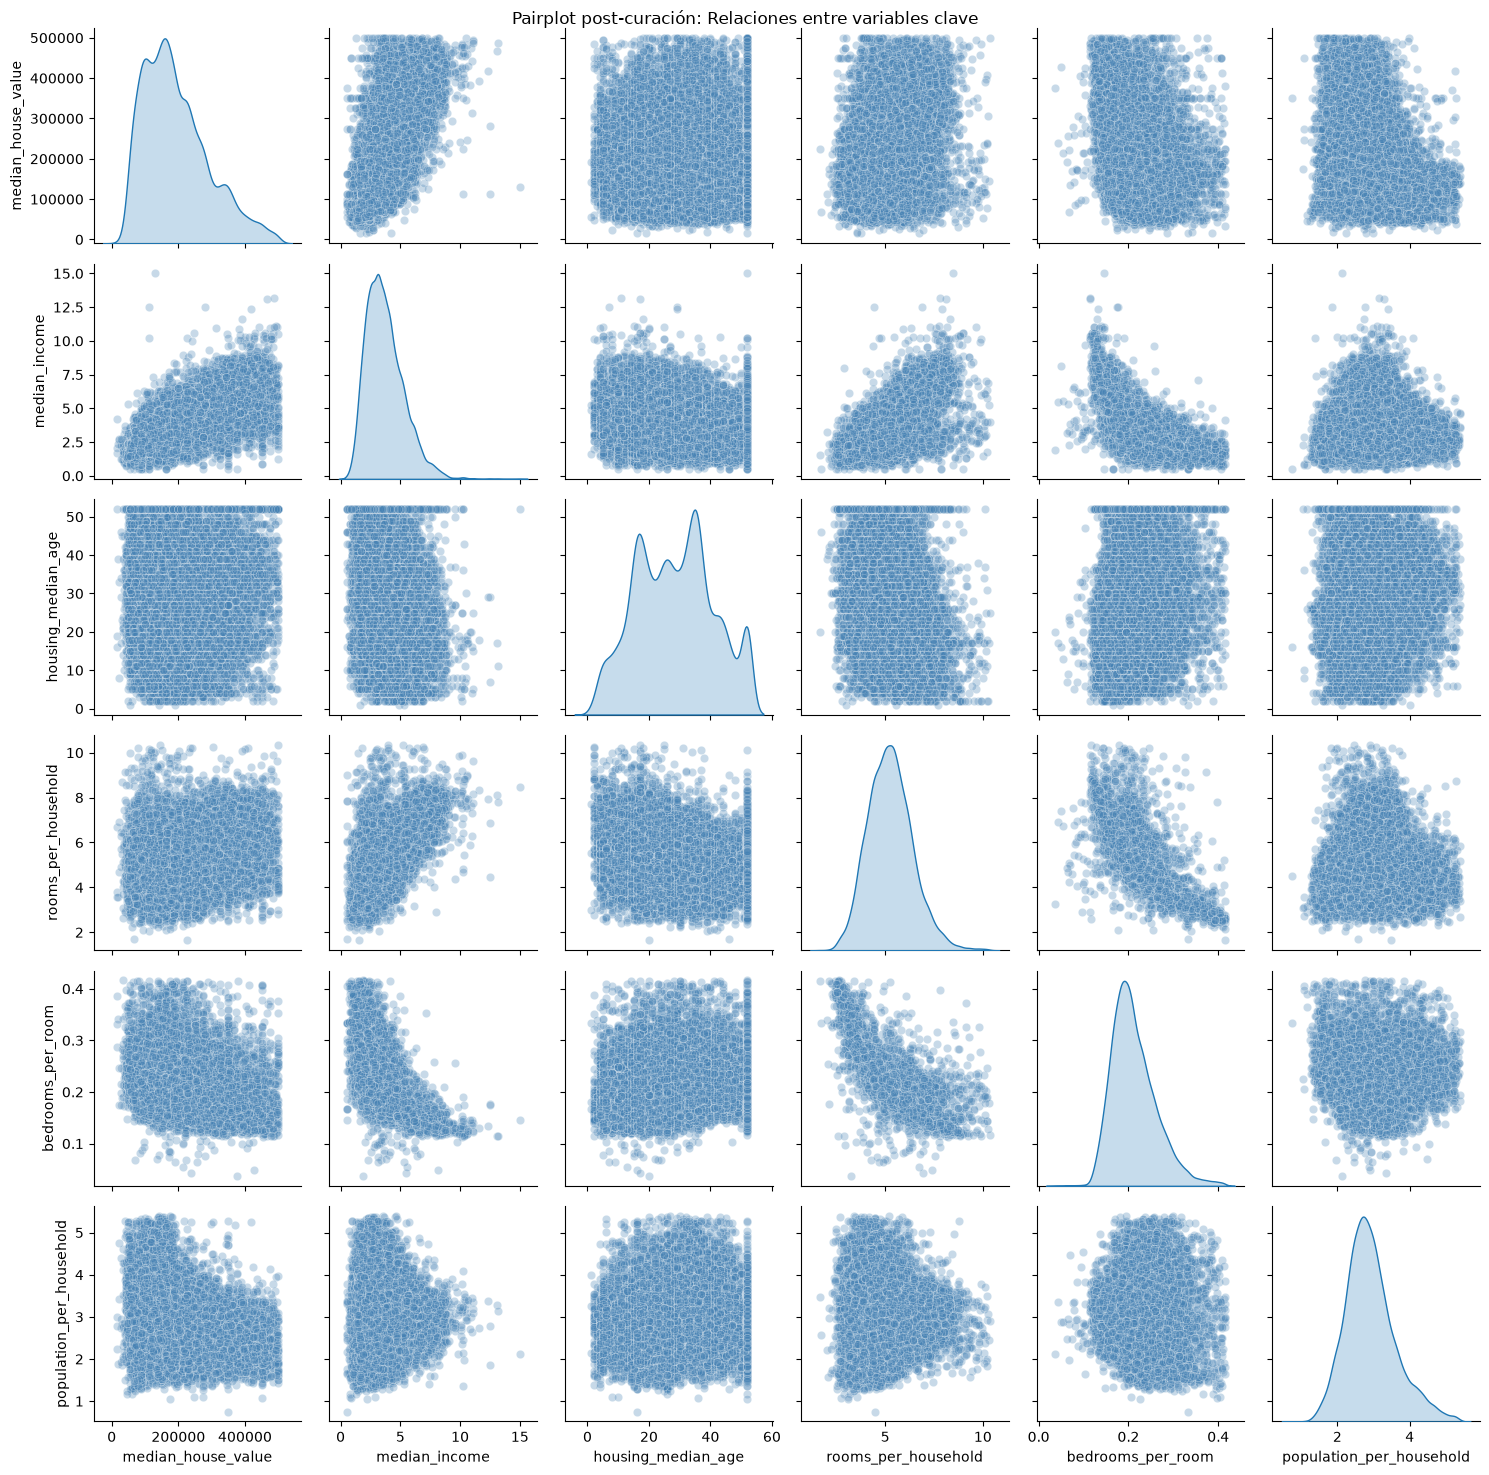

In [14]:
columnas_pairplot = [
    'median_house_value',
    'median_income',
    'housing_median_age',
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household'
]

sns.pairplot(
    df_clean[columnas_pairplot],
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 'color': 'steelblue'},
)

plt.suptitle('Pairplot post-curación: Relaciones entre variables clave')
plt.tight_layout()
plt.show()

## Matriz de Correlación de Pearson (df_clean)
Recalculo de correlaciones sobre el dataset curado. Los ratios derivados
se incluyen automáticamente al estar presentes en df_clean.

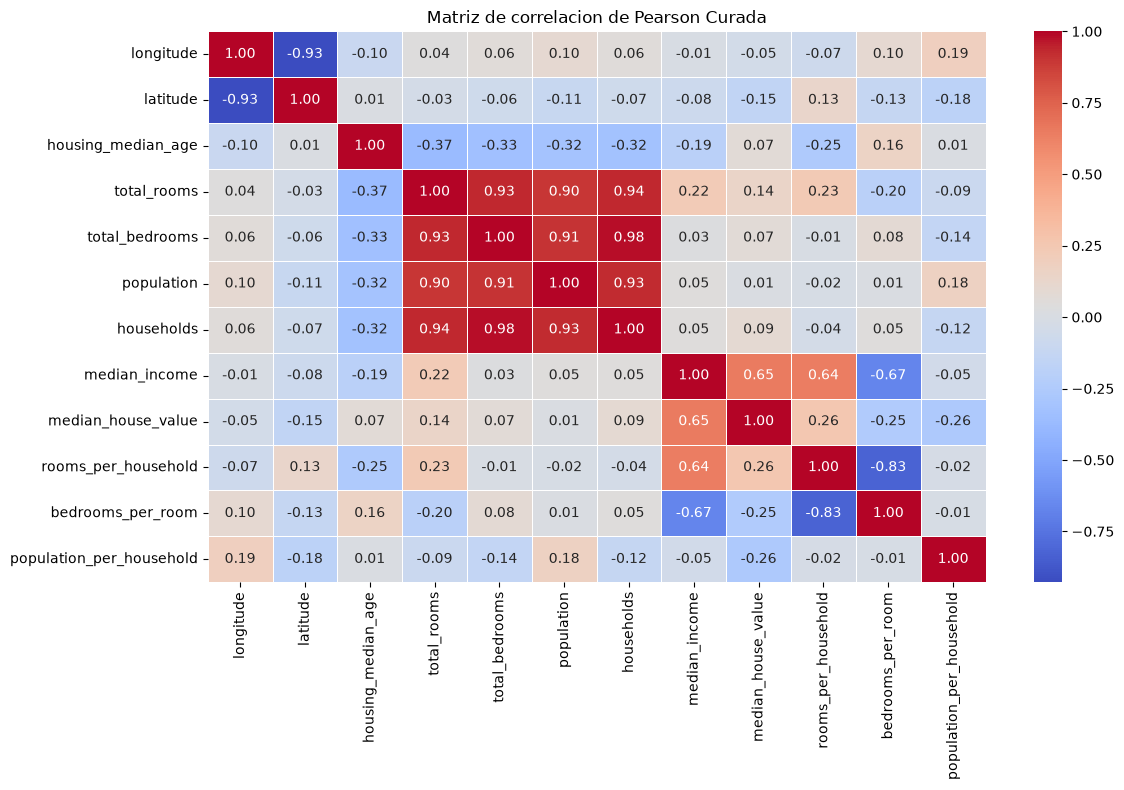

In [15]:
#mapa de correlacion de Pearson

#filtrar solo la columna numerica
columnas_numericas = df_clean.select_dtypes(include=[np.number])

#calcular la matriz matematica de correlacion
matriz_correlacion = columnas_numericas.corr()

#dibujar mapa de calor
plt.figure(figsize=(12, 8))

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Matriz de correlacion de Pearson Curada')
plt.tight_layout()
plt.show()


## Análisis Visual de Ratios Derivados vs Precio
Los ratios estructurales creados anteriormente se analizan aquí contra
la variable objetivo. El heatmap confirmó correlaciones moderadas —
estos scatters muestran la forma visual de cada relación.

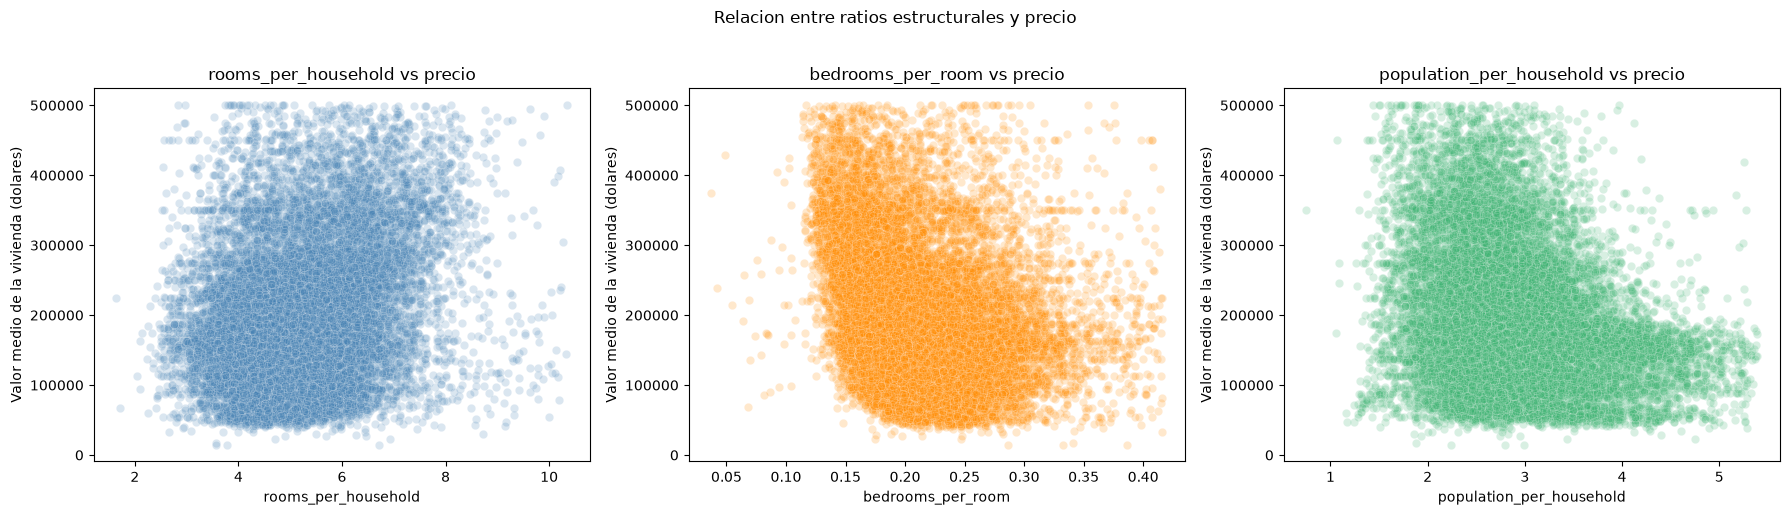

In [16]:
#tres scatters en fila: uno por cada ratio derivado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#pares ratio → color para distinguirlos visualmente
ratios  = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
colores = ['steelblue', 'darkorange', 'mediumseagreen']

for ax, ratio, color in zip(axes, ratios, colores): #zip() hace que el bucle recorra los 3 al mismo tiempo
    sns.scatterplot(
        data=df_clean,
        x=ratio,
        y='median_house_value',
        alpha=0.2,
        color=color,
        ax=ax
    )
    ax.set_xlabel(ratio)
    ax.set_ylabel('Valor medio de la vivienda (dolares)')
    ax.set_title(f'{ratio} vs precio')

plt.suptitle('Relacion entre ratios estructurales y precio', y=1.02)
plt.tight_layout()
plt.show()

## Analisis Segmentado: Impacto de la Ubicación Geográfica
Evaluación de la distribución del valor de las propiedades segmentado por la variable categórica de proximidad al océano, aislando la influencia del entorno físico sobre el precio.

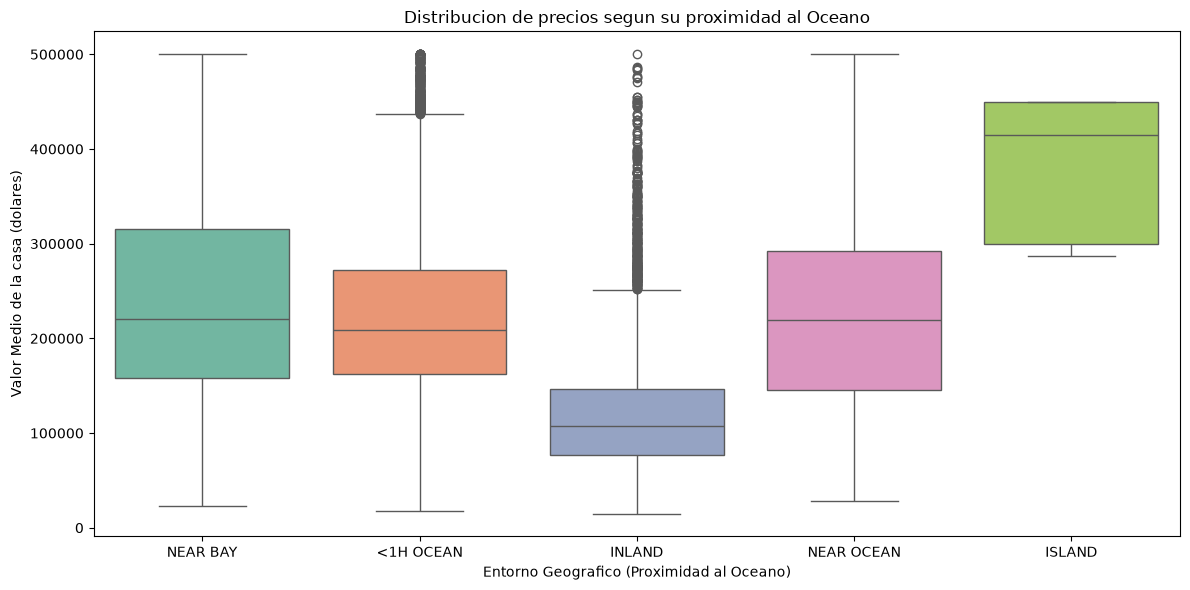

In [17]:
plt.figure(figsize=(12, 6))

#dibujar un boxplot
sns.boxplot(data=df_clean, x='ocean_proximity', y='median_house_value', palette='Set2')

plt.title('Distribucion de precios segun su proximidad al Oceano')
plt.xlabel('Entorno Geografico (Proximidad al Oceano)')
plt.ylabel('Valor Medio de la casa (dolares)')

plt.tight_layout()
plt.show()

## Distribución Geográfica del Precio de Vivienda
Visualización de los bloques censales en su posición geográfica real,
coloreados por precio. Permite identificar patrones espaciales que los
análisis numéricos anteriores no pueden revelar.

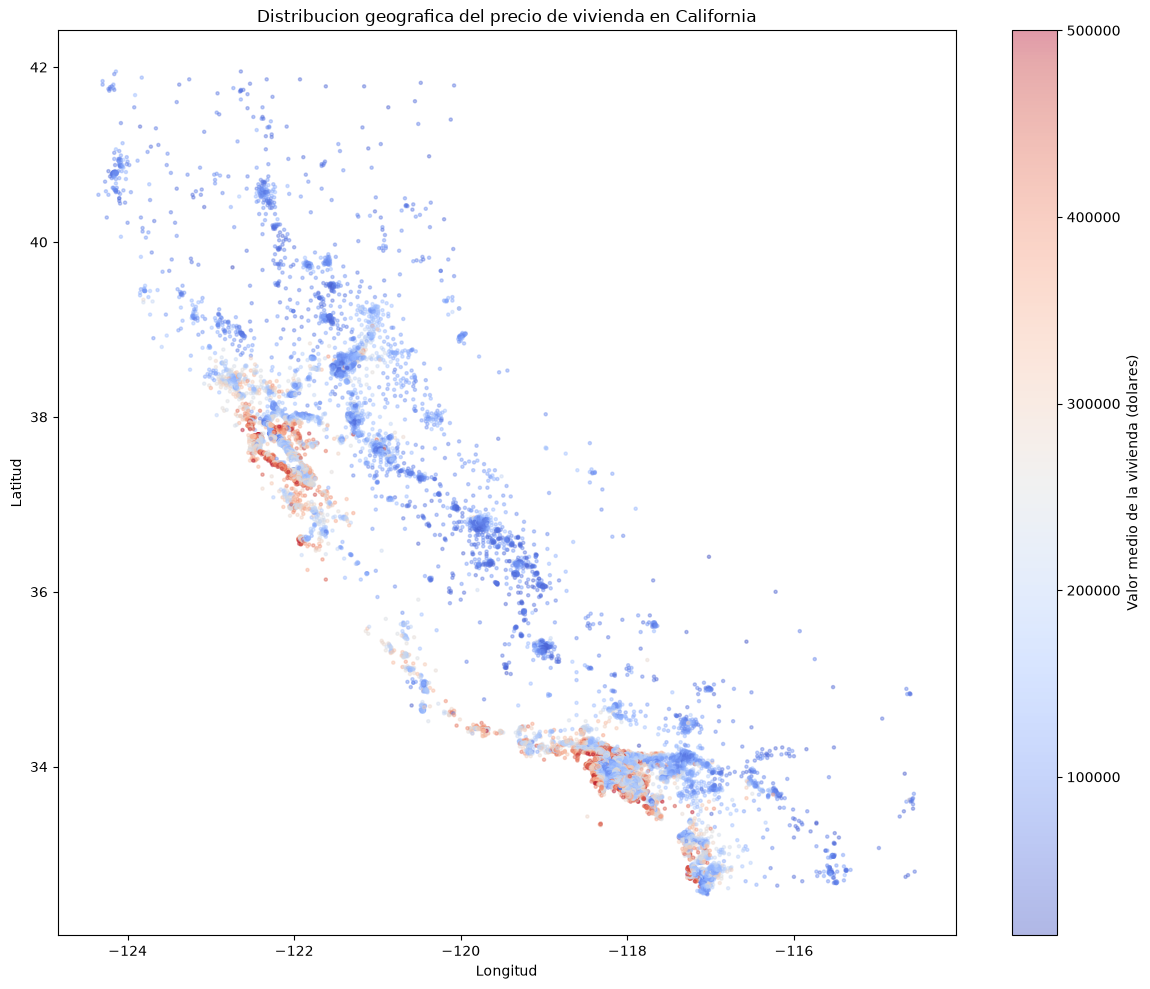

In [18]:
plt.figure(figsize=(12, 10))

#cada punto es un bloque censal en su posicion geografica real
scatter = plt.scatter(
    x=df_clean['longitude'],
    y=df_clean['latitude'],
    c=df_clean['median_house_value'],  #la variable que define el color
    cmap='coolwarm',                   #azul=barato, rojo=caro
    alpha=0.4,                         #transparencia para ver densidad
    s=5
)

#barra de color que explica la escala
plt.colorbar(scatter, label='Valor medio de la vivienda (dolares)')

plt.title('Distribucion geografica del precio de vivienda en California')
plt.xlabel('Longitud')
plt.ylabel('Latitud')

plt.tight_layout()
plt.show()

# Conclusiones del Análisis Exploratorio

### ¿Qué hace que las casas sean tan caras en California?

**1. El ingreso del vecindario es el predictor más fuerte**
`median_income` tiene una correlación de 0.65 con el precio, la más alta del dataset. Los bloques censales con mayor poder adquisitivo concentran las propiedades más caras, independientemente de su ubicación o antigüedad.

**2. La geografía importa, pero no de forma lineal**
`latitude` y `longitude` individualmente muestran correlaciones bajas con el precio. Sin embargo, el mapa geográfico revela dos clusters de alto valor claramente definidos: el Área de la Bahía de San Francisco y la costa de Los Ángeles. La relación entre ubicación y precio es predominantemente espacial y no lineal, por lo que la correlación de Pearson no logra capturarla adecuadamente.

**3. La proximidad al océano eleva el precio**
Los bloques categorizados como `ISLAND` y `NEAR OCEAN` tienen medianas de precio notablemente más altas que el resto. `INLAND` es consistentemente el grupo con los precios más bajos.

**4. El dataset tiene limitaciones estructurales documentadas**
Se detectaron techos artificiales en tres columnas:

* `median_house_value`: truncado en $500,001 (4.68% de los registros).
* `housing_median_age`: truncado en 52 años (6.17% de los registros).
* `median_income`: truncado en 15 (0.24% de los registros).

Solo se filtró `median_house_value` por tratarse de la variable objetivo; un techo en la etiqueta corrompe cualquier análisis de precios. Los techos en variables predictoras con baja correlación no justificaron el costo de eliminar registros adicionales.

**5. Los ratios derivados revelan patrones ocultos**
Tras la limpieza, `rooms_per_household` mostró una correlación de 0.64 con `median_income` (frente a 0.33 antes de la limpieza). Los outliers estaban atenuando una relación subyacente entre ambas variables: los barrios de mayor ingreso tienden a tener viviendas más amplias.

Por otro lado, `bedrooms_per_room` correlaciona negativamente con el precio y el ingreso, lo que sugiere que las viviendas más caras destinan una mayor proporción de su espacio a áreas distintas de los dormitorios.
